![earthkit-meteo-logo](https://github.com/ecmwf/logos/raw/refs/heads/main/logos/earthkit/earthkit-meteo-light.svg)

# Earthkit-meteo: wind computations

In this notebook you will see how to:

- compute the wind speed from NetCDF/Xarray and GRIB data

In [1]:
import earthkit.data as ekd
from earthkit.meteo import wind
import earthkit.plots as ekp

### Xarray

In [2]:
ds = ekd.from_source("sample", "era5_tquv_pl_subarea.nc").to_xarray()
ds

era5_tquv_pl_subarea.nc:   0%|          | 0.00/14.6M [00:00<?, ?B/s]

<xarray.Dataset> Size: 35MB
Dimensions:         (valid_time: 4, pressure_level: 3, latitude: 301,
                     longitude: 601)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Data variables:
    q               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 9MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-12T10:30 GRIB to CDM+CF via cfgrib-0.9.1...

Next, we compute the wind speed with [earthkit.meteo.wind.speed](https://earthkit-meteo.readthedocs.io/en/release-1.0.0rc0/autoapi/earthkit/meteo/wind/xarray/speed.html#earthkit.meteo.wind.xarray.wind). We pass DataArrays to this method.

In [3]:
sp = wind.speed(ds.u,ds.v)
sp

<xarray.DataArray 'u' (valid_time: 4, pressure_level: 3, latitude: 301,
                       longitude: 601)> Size: 9MB
array([[[[7.21209857e-04, 7.21209857e-04, 7.21209857e-04, ...,
          7.21209857e-04, 7.21209857e-04, 7.21209857e-04],
         [9.15587044e+00, 9.15572071e+00, 9.15571594e+00, ...,
          9.67847347e+00, 9.67668724e+00, 9.67551231e+00],
         [8.77466106e+00, 8.77321625e+00, 8.77142429e+00, ...,
          9.91900063e+00, 9.91710377e+00, 9.91543484e+00],
         ...,
         [1.12219691e+00, 1.00199103e+00, 8.06946635e-01, ...,
          9.93535876e-01, 4.55393404e-01, 6.65705085e-01],
         [4.73718941e-01, 4.93476927e-01, 5.56098044e-01, ...,
          5.67884982e-01, 7.18522072e-01, 4.60717976e-01],
         [1.05491556e-01, 3.18013817e-01, 4.84191030e-01, ...,
          9.93801832e-01, 6.87026620e-01, 4.87377763e-01]],

        [[1.04129361e-03, 1.04129361e-03, 1.04129361e-03, ...,
          1.04129361e-03, 1.04129361e-03, 1.04129361e-03],
         [8.28795815e+00, 8.29496670e+00, 8.30037975e+00, ...,
          8.25793839e+00, 8.25712204e+00, 8.25645351e+00],
         [8.83082581e+00, 8.84640408e+00, 8.86025906e+00, ...,
          8.32423401e+00, 8.32343578e+00, 8.32278347e+00],
...
          1.70103025e+00, 1.26007354e+00, 1.77098072e+00],
         [2.65315723e+00, 2.73314214e+00, 2.64034247e+00, ...,
          2.76825452e+00, 2.20397377e+00, 2.17171168e+00],
         [2.73072147e+00, 2.88751960e+00, 2.87780690e+00, ...,
          2.61288738e+00, 2.68276882e+00, 2.50446677e+00]],

        [[6.33009884e-04, 6.33009884e-04, 6.33009884e-04, ...,
          6.33009884e-04, 6.33009884e-04, 6.33009884e-04],
         [7.87639523e+00, 7.87548780e+00, 7.87472439e+00, ...,
          7.88470078e+00, 7.88728619e+00, 7.89145756e+00],
         [7.69088745e+00, 7.68987322e+00, 7.68869591e+00, ...,
          7.31118202e+00, 7.31721783e+00, 7.32209921e+00],
         ...,
         [3.76584339e+00, 4.03104496e+00, 4.31973362e+00, ...,
          9.29071903e+00, 7.57689333e+00, 6.01164341e+00],
         [4.17330790e+00, 4.29592800e+00, 4.42056227e+00, ...,
          8.29728794e+00, 6.92111635e+00, 5.99423361e+00],
         [4.42543697e+00, 4.44226933e+00, 4.52274704e+00, ...,
          6.44288826e+00, 6.02955246e+00, 6.10808563e+00]]]],
      shape=(4, 3, 301, 601), dtype=float32)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 32B 2016-09-26 ... 2016-09-26...
  * pressure_level  (pressure_level) float64 24B 925.0 850.0 700.0
  * latitude        (latitude) float64 2kB 90.0 89.75 89.5 ... 15.5 15.25 15.0
  * longitude       (longitude) float64 5kB -100.0 -99.75 -99.5 ... 49.75 50.0
Attributes: (12/31)
    GRIB_paramId:                             131
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      180901
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           u
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                U component of wind
    units:                                    m s**-1
    standard_name:                            eastward_wind

Earthkit-meteo is still work in progress and the metadata is not yet set in the resulting DataArray. We will set it manually.

In [4]:
sp.attrs["standard_name"] = "wind_speed"
sp.attrs["long_name"] = "wind_speed"
sp = sp.rename("ws")

Finally, we plot some of the data for visual checking.

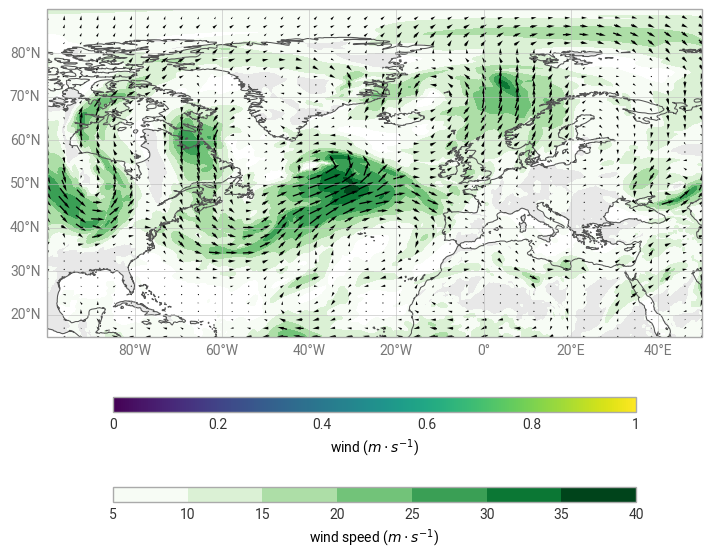

In [5]:
# select one level and step and plot wind field overlaid with the computed speed
u = ds.u.sel(pressure_level=700, valid_time="2016-09-26T12")
v = ds.v.sel(pressure_level=700, valid_time="2016-09-26T12")
sp1 = sp.sel(pressure_level=700, valid_time="2016-09-26T12")

chart = ekp.Map()
chart.contourf(sp1, units="m s-1", colors="Greens", 
               levels=list(range(5,45,5)), alpha=1)

chart.quiver(u=u, v=v, headwidth=2.5, width=0.002)

# Add map features
chart.coastlines()
chart.land()
chart.gridlines()
chart.legend()

# Show the plot
chart.show()